# What kinds of records are in the regional data-center inventory?

The [Tampa Bay Regional Planning Council layer](https://services3.arcgis.com/RgIBbQIF0Y6T3AX6/arcgis/rest/services/Tampa_Bay_Region_Data_Centers/FeatureServer/0) mixes locations and project statuses. This story checks status by county and audits `Estimated_Size` before any size comparison. It is a research inventory, not a census of operating facilities or an authoritative site list.


## 1. Read all records with their source context


In [1]:
library(tampaBayOpenData)

centers <- tbod_get_dataset(
  "tbrpc-regional-data-centers",
  fields = c("OBJECTID", "County", "Status", "Estimated_Size", "Data_Source"),
  total_timeout = 120
)
source <- tbod_provenance(centers)
stopifnot(isTRUE(source$complete), nrow(centers) == source$returned_rows)
print(data.frame(publisher = source$publisher, retrieved_at = source$retrieved_at,
                 records = nrow(centers), integrity = source$integrity))


                            publisher        retrieved_at records     integrity
1 Tampa Bay Regional Planning Council 2026-10-06 22:42:20      15 full-manifest


## 2. Separate current facilities from other statuses

Counts are record counts in this particular research layer. The status labels are source values; the notebook does not independently verify an individual site's operating status.


              status
county         Existing Rejected Withdrawn
  Citrus              0        0         1
  Hillsborough       13        0         0
  Pinellas            0        1         0


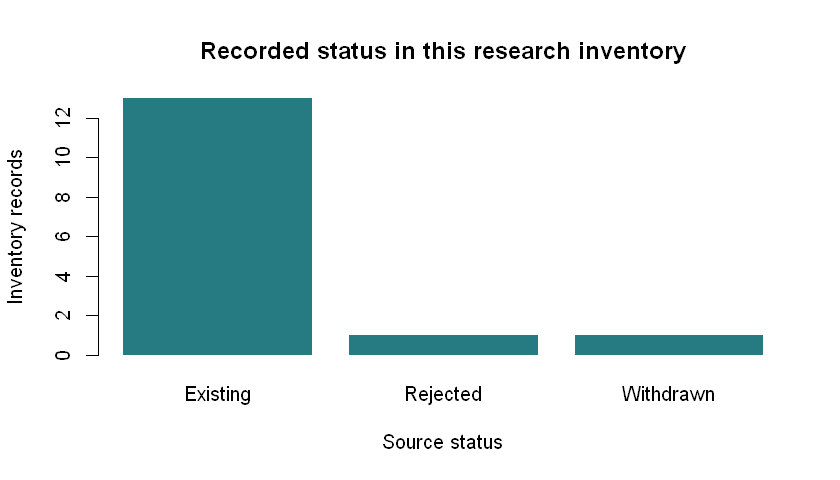

In [2]:
clean_label <- function(x) {
  value <- trimws(as.character(x))
  value[is.na(value) | value == ""] <- "(missing)"
  value
}
county <- clean_label(centers$County)
status <- clean_label(centers$Status)
status_by_county <- table(county, status)
print(status_by_county)

options(repr.plot.width = 7, repr.plot.height = 4)
barplot(colSums(status_by_county), col = "#267b83", border = NA,
        ylab = "Inventory records", xlab = "Source status",
        main = "Recorded status in this research inventory")


## 3. Audit the size field and cited sources

`Estimated_Size` is text and can contain different units. We classify its written unit rather than treating every number as comparable floor space. A URL in `Data_Source` indicates a citation is present; it does not validate the cited claim.


In [3]:
size_text <- clean_label(centers$Estimated_Size)
size_unit <- ifelse(grepl("square feet", size_text, ignore.case = TRUE), "square feet",
             ifelse(grepl("acres?", size_text, ignore.case = TRUE), "acres", "other/missing"))
cited_url <- !is.na(centers$Data_Source) &
  grepl("^https?://", trimws(as.character(centers$Data_Source)))
print(table(status, size_unit))
print(data.frame(records = nrow(centers), records_with_source_url = sum(cited_url),
                 records_with_unparsed_size_unit = sum(size_unit == "other/missing")))
print(utils::head(data.frame(status, size = size_text, size_unit), 6))


           size_unit
status      acres square feet
  Existing      0          13
  Rejected      0           1
  Withdrawn     1           0


  records records_with_source_url records_with_unparsed_size_unit
1      15                      15                               0


    status               size   size_unit
1 Existing 100000 square feet square feet
2 Existing  76000 square feet square feet
3 Existing  23000 square feet square feet
4 Existing  25000 square feet square feet
5 Existing  30000 square feet square feet
6 Existing  12000 square feet square feet


## What this means

Status and measurement unit must be resolved before comparing capacities or summing sizes. The layer can guide follow-up research, but its small, selected inventory cannot support a countywide prevalence claim.
